# Clean A/B Test Analysis

A concise analysis of whether the treatment landing page changes conversion rate.

Workflow: load → validate → clean → compare → test → adjust for country → segment → Bayesian check → conclude.

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.formula.api import logit

np.random.seed(42)

ab = pd.read_csv("ab_data.csv")
countries = pd.read_csv("countries.csv")
ab["timestamp"] = pd.to_datetime(ab["timestamp"])

display(ab.head())
display(countries.head())
print("A/B shape:", ab.shape, "| Countries shape:", countries.shape)

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


A/B shape: (294478, 5) | Countries shape: (290584, 2)


## 2. Validate and Clean Data

In [3]:
print("Missing values:")
display(ab.isna().sum())

print("Duplicate users:", ab["user_id"].duplicated().sum())
display(pd.crosstab(ab["group"], ab["landing_page"]))

valid = (
    ((ab["group"] == "control") & (ab["landing_page"] == "old_page")) |
    ((ab["group"] == "treatment") & (ab["landing_page"] == "new_page"))
)

df = (
    ab.loc[valid]
      .sort_values("timestamp")
      .drop_duplicates("user_id", keep="first")
      .merge(countries, on="user_id", how="inner")
)

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()
df["is_weekend"] = df["timestamp"].dt.dayofweek >= 5

print(f"Rows: {len(ab):,} -> {len(df):,}")
print(f"Unique users: {df['user_id'].nunique():,}")

Missing values:


user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

Duplicate users: 3894


landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


Rows: 294,478 -> 290,584
Unique users: 290,584


## 3. Conversion Rates

In [4]:
summary = df.groupby("group")["converted"].agg(
    users="count",
    conversions="sum",
    conversion_rate="mean"
)
summary["conversion_rate_pct"] = summary["conversion_rate"] * 100
display(summary)

control_rate = summary.loc["control", "conversion_rate"]
treatment_rate = summary.loc["treatment", "conversion_rate"]
difference = treatment_rate - control_rate

print(f"Control:   {control_rate:.3%}")
print(f"Treatment: {treatment_rate:.3%}")
print(f"Difference: {difference:.3%}")

,users,conversions,conversion_rate,conversion_rate_pct
group,,,,
control,145274,17489,0.120386,12.038630
treatment,145310,17264,0.118808,11.880807


Control:   12.039%
Treatment: 11.881%
Difference: -0.158%


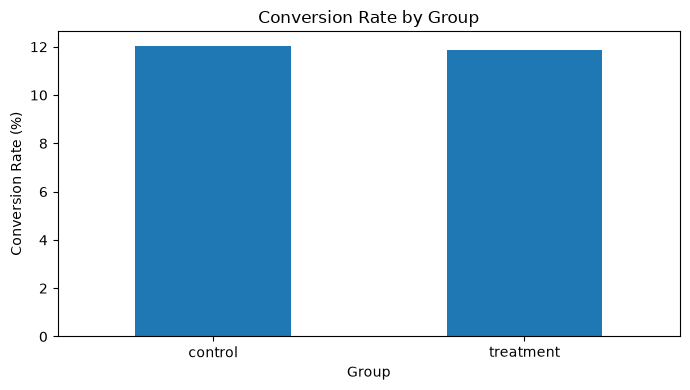

In [5]:
summary["conversion_rate_pct"].plot(
    kind="bar", figsize=(7, 4), rot=0,
    title="Conversion Rate by Group",
    xlabel="Group", ylabel="Conversion Rate (%)"
)
plt.tight_layout()
plt.show()

## 4. Two-Proportion Z-Test

H0: control and treatment conversion rates are equal.  
H1: the conversion rates are different.

In [6]:
control = df[df["group"] == "control"]
treatment = df[df["group"] == "treatment"]

n_control, n_treatment = len(control), len(treatment)
conv_control = int(control["converted"].sum())
conv_treatment = int(treatment["converted"].sum())

z_stat, p_value = proportions_ztest(
    [conv_treatment, conv_control],
    [n_treatment, n_control]
)

ci_control = proportion_confint(conv_control, n_control, alpha=0.05)
ci_treatment = proportion_confint(conv_treatment, n_treatment, alpha=0.05)

print(f"Z = {z_stat:.4f}")
print(f"p = {p_value:.4f}")
print(f"Control 95% CI:   {ci_control[0]:.3%} to {ci_control[1]:.3%}")
print(f"Treatment 95% CI: {ci_treatment[0]:.3%} to {ci_treatment[1]:.3%}")
print("Decision:", "Reject H0" if p_value < 0.05 else "Fail to reject H0")

Z = -1.3109
p = 0.1899
Control 95% CI:   11.871% to 12.206%
Treatment 95% CI: 11.714% to 12.047%
Decision: Fail to reject H0


## 5. Logistic Regression: Adjust for Country

In [7]:
model_df = df.copy()
model_df["is_treatment"] = (model_df["group"] == "treatment").astype(int)

model = logit("converted ~ is_treatment + C(country)", data=model_df).fit(disp=False)
display(model.summary2().tables[1])

treatment_p = model.pvalues["is_treatment"]
odds_ratio = np.exp(model.params["is_treatment"])

print(f"Treatment odds ratio: {odds_ratio:.4f}")
print(f"Treatment p-value: {treatment_p:.4f}")

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-2.030029,0.026624,-76.248769,0.000000,-2.082210,-1.977847
C(country)[T.UK],0.050640,0.028393,1.783532,0.074500,-0.005009,0.106290
C(country)[T.US],0.040757,0.026883,1.516071,0.129501,-0.011933,0.093447
is_treatment,-0.014943,0.011434,-1.306905,0.191245,-0.037354,0.007467


Treatment odds ratio: 0.9852
Treatment p-value: 0.1912


## 6. Country Segmentation

,country,group,users,conversion_rate,conversion_rate_pct
0,CA,control,7198,0.118783,11.878300
1,CA,treatment,7301,0.111902,11.190248
2,UK,control,36360,0.120022,12.002200
3,UK,treatment,36106,0.121171,12.117100
4,US,control,101716,0.120630,12.062999
5,US,treatment,101903,0.118466,11.846560


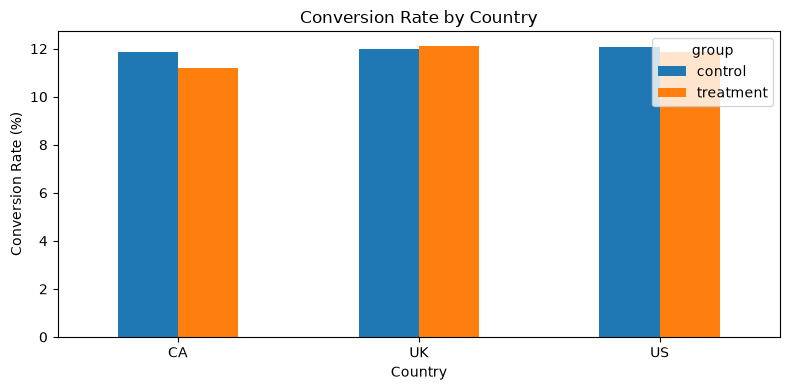

In [8]:
country_summary = (
    df.groupby(["country", "group"])["converted"]
      .agg(users="count", conversion_rate="mean")
      .reset_index()
)
country_summary["conversion_rate_pct"] = country_summary["conversion_rate"] * 100
display(country_summary)

country_summary.pivot(
    index="country", columns="group", values="conversion_rate_pct"
).plot(
    kind="bar", figsize=(8, 4), rot=0,
    title="Conversion Rate by Country",
    xlabel="Country", ylabel="Conversion Rate (%)"
)
plt.tight_layout()
plt.show()

## 7. Bayesian Check

In [9]:
control_samples = beta.rvs(
    1 + conv_control, 1 + n_control - conv_control,
    size=100_000, random_state=42
)
treatment_samples = beta.rvs(
    1 + conv_treatment, 1 + n_treatment - conv_treatment,
    size=100_000, random_state=43
)

prob_better = np.mean(treatment_samples > control_samples)
expected_lift = np.mean(treatment_samples - control_samples)

print(f"P(treatment > control): {prob_better:.2%}")
print(f"Expected absolute lift: {expected_lift:.3%}")

P(treatment > control): 9.59%
Expected absolute lift: -0.158%


## 8. Conclusion

In [10]:
print(f"Control conversion:   {control_rate:.3%}")
print(f"Treatment conversion: {treatment_rate:.3%}")
print(f"Difference:           {difference:.3%}")
print(f"Z-test p-value:       {p_value:.4f}")
print(f"Adjusted p-value:     {treatment_p:.4f}")
print(f"P(treatment better):  {prob_better:.2%}")

if p_value < 0.05 and difference > 0:
    print("Conclusion: Treatment significantly improves conversion.")
elif p_value < 0.05:
    print("Conclusion: Treatment significantly reduces conversion.")
else:
    print("Conclusion: No statistically significant improvement from treatment.")

Control conversion:   12.039%
Treatment conversion: 11.881%
Difference:           -0.158%
Z-test p-value:       0.1899
Adjusted p-value:     0.1912
P(treatment better):  9.59%
Conclusion: No statistically significant improvement from treatment.
